In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/Data1.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data1.csv


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt resources downloaded.


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Apply the function to the 'Questions' column
df['Processed_Questions'] = df['Questions'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Questions' column.")
display(df[['Questions', 'Processed_Questions']].head())

Stop word reduction and tokenization applied to 'Questions' column.


,Questions,Processed_Questions
0,About what proportion of the population of the...,"[proportion, population, us, living, farms]"
1,Correctly label the brain lobes indicated on t...,"[correctly, label, brain, lobes, indicated, di..."
2,Define compound interest.,"[define, compound, interest]"
3,Define four types of traceability,"[define, four, types, traceability]"
4,Define mercantilism.,"[define, mercantilism]"


In [6]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Questions', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Questions,Processed_Questions,Processed_Questions_Str
0,About what proportion of the population of the...,"[proportion, population, us, living, farms]",proportion population us living farms
1,Correctly label the brain lobes indicated on t...,"[correctly, label, brain, lobes, indicated, di...",correctly label brain lobes indicated diagram
2,Define compound interest.,"[define, compound, interest]",define compound interest
3,Define four types of traceability,"[define, four, types, traceability]",define four types traceability
4,Define mercantilism.,"[define, mercantilism]",define mercantilism


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the 'Processed_Questions_Str' column
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Processed_Questions_Str'])

print("TF-IDF vectorization applied. Shape of TF-IDF matrix:")
print(tfidf_matrix.shape)

TF-IDF vectorization applied. Shape of TF-IDF matrix:
(8762, 8553)


# Task
Prepare the TF-IDF features and the encoded target variable from the 'Category' column of the DataFrame for training a Support Vector Machine (SVM) model.

## Prepare Data for SMOTE and SVM

### Subtask:
Prepare the features (TF-IDF matrix) and the target variable (encoded 'Category' column) from the DataFrame for use with SMOTE and SVM.


**Reasoning**:
To prepare the data for SMOTE and SVM, I need to encode the categorical 'Category' column into numerical labels. I will use `LabelEncoder` for this purpose.



In [8]:
from sklearn.preprocessing import LabelEncoder

# Instantiate LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Category' column
df['Category_Encoded'] = label_encoder.fit_transform(df['Category'])

print("Encoded 'Category' column into 'Category_Encoded'.")
print("Mapping of original categories to encoded values:")
for i, category in enumerate(label_encoder.classes_):
    print(f"{category}: {i}")
display(df[['Category', 'Category_Encoded']].head())

Encoded 'Category' column into 'Category_Encoded'.
Mapping of original categories to encoded values:
Analyse: 0
Apply: 1
Create: 2
Evaluate: 3
Remember: 4
Understand: 5


,Category,Category_Encoded
0,Remember,4
1,Remember,4
2,Remember,4
3,Remember,4
4,Remember,4


**Reasoning**:
Now that the target variable ('Category') has been encoded into numerical labels, I need to explicitly separate the features (TF-IDF matrix) and the target variable ('Category_Encoded') into `X` and `y` variables, respectively, which is a standard practice for machine learning models like SVM and for use with techniques like SMOTE.



In [9]:
X = tfidf_matrix
y = df['Category_Encoded']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (8762, 8553)
Target (y) shape: (8762,)


## Implement Cross-Validation with SMOTE and SVM

### Subtask:
Set up a Stratified K-Fold cross-validation. Within each fold, apply SMOTE to the training data to balance class distributions before training an SVM classifier. Evaluate the model on the test set of each fold.


**Reasoning**:
I need to import the required libraries for cross-validation, SMOTE, and SVM, then set up and run the Stratified K-Fold cross-validation loop as instructed, applying SMOTE within each fold before training the SVM model, and finally collecting and printing the evaluation metrics.



In [10]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 2. Initialize StratifiedKFold
n_splits = 5 # Can be adjusted, 5 or 10 are common choices
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 3. Initialize SMOTE
smote = SMOTE(random_state=42)

# 4. Initialize SVC (Support Vector Classifier)
svm_model = SVC(kernel='linear', random_state=42, probability=True) # probability=True to enable predict_proba if needed later

# 5. Create empty lists to store the classification reports and accuracy scores for each fold.
reports = []
accuracies = []

print(f"Starting Stratified K-Fold Cross-Validation with {n_splits} splits...")

# 6. Iterate through the splits generated by skf.split(X, y).
for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    # 7a. Obtain the training and test indices.
    # 7b. Split X and y into X_train, X_test, y_train, y_test using these indices.
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # 7c. Apply SMOTE to the training data
    print(f"Applying SMOTE to training data (original train samples: {len(y_train)})...")
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    print(f"Resampled training data samples after SMOTE: {len(y_resampled)}")

    # 7d. Train the SVM model on the resampled training data
    print("Training SVM model...")
    svm_model.fit(X_resampled, y_resampled)
    print("SVM model training complete.")

    # 7e. Make predictions on the original (non-resampled) test data
    y_pred = svm_model.predict(X_test)

    # 7f. Calculate the accuracy score and append it to the accuracy list.
    fold_accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(fold_accuracy)
    print(f"Accuracy for Fold {fold+1}: {fold_accuracy:.4f}")

    # 7g. Generate a classification report using y_test and y_pred, and append it to the reports list.
    fold_report = classification_report(y_test, y_pred, output_dict=True)
    reports.append(fold_report)
    print(f"Classification Report for Fold {fold+1}:\n{classification_report(y_test, y_pred)}")

# 8. After the loop, print the average accuracy across all folds and all classification reports.
print("\n--- Cross-Validation Results ---")
print(f"Average Accuracy across {n_splits} folds: {np.mean(accuracies):.4f}")
print("Individual Fold Accuracies:")
for i, acc in enumerate(accuracies):
    print(f"  Fold {i+1}: {acc:.4f}")

print("\nFull Classification Reports (one for each fold):")
# You can choose to process and display these reports more concisely if needed
# For now, we'll just indicate they are stored.
# For a more detailed aggregated report, further processing would be needed.
for i, report in enumerate(reports):
    print(f"\nClassification Report for Fold {i+1}:")
    for label, metrics in report.items():
        if isinstance(metrics, dict):
            print(f"  {label}:\n    Precision: {metrics['precision']:.2f}, Recall: {metrics['recall']:.2f}, F1-score: {metrics['f1-score']:.2f}, Support: {metrics['support']}")
        else:
            print(f"  {label}: {metrics:.2f}")


Starting Stratified K-Fold Cross-Validation with 5 splits...

--- Fold 1/5 ---
Applying SMOTE to training data (original train samples: 7009)...
Resampled training data samples after SMOTE: 12390
Training SVM model...
SVM model training complete.
Accuracy for Fold 1: 0.7210
Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.64      0.72      0.68       258
           1       0.80      0.71      0.75       301
           2       0.89      0.87      0.88       160
           3       0.86      0.88      0.87       157
           4       0.68      0.74      0.71       517
           5       0.65      0.58      0.61       360

    accuracy                           0.72      1753
   macro avg       0.75      0.75      0.75      1753
weighted avg       0.72      0.72      0.72      1753


--- Fold 2/5 ---
Applying SMOTE to training data (original train samples: 7009)...
Resampled training data samples after SMOTE: 12390
Training SVM 

## Evaluate and Summarize Model Performance

### Subtask:
Collect and analyze the performance metrics (e.g., accuracy, precision, recall, F1-score) from all cross-validation folds. Visualize the aggregated results, if appropriate, to provide a clear understanding of the model's performance.


**Reasoning**:
To provide an overall measure of model accuracy and its variability, I will calculate and print the mean and standard deviation of the `accuracies` list. This fulfills the first instruction of the subtask.



In [11]:
print(f"Mean accuracy across all folds: {np.mean(accuracies):.4f}")
print(f"Standard deviation of accuracy across all folds: {np.std(accuracies):.4f}")

Mean accuracy across all folds: 0.7182
Standard deviation of accuracy across all folds: 0.0072


**Reasoning**:
To fulfill the second instruction of the subtask, I need to aggregate the classification reports by calculating the average precision, recall, and F1-score for each class and for the 'macro avg' and 'weighted avg' across all folds. This involves iterating through the `reports` list and summing up the corresponding metrics.



In [12]:
aggregated_report = {}
num_folds = len(reports)

# Get all unique labels (class labels + macro avg + weighted avg)
all_labels = set()
for report in reports:
    all_labels.update(report.keys())

for label in sorted(list(all_labels)):
    if label == 'accuracy': # Accuracy is handled separately
        continue

    # Initialize sums for precision, recall, f1-score, and support
    total_precision = 0
    total_recall = 0
    total_f1_score = 0
    total_support = 0 # Support is usually constant or similar across folds for stratified splits

    count_valid_folds = 0 # To handle cases where a label might be missing in a fold (though unlikely with stratified KFold)

    for report in reports:
        if label in report:
            metrics = report[label]
            if isinstance(metrics, dict): # For class labels, macro avg, weighted avg
                total_precision += metrics['precision']
                total_recall += metrics['recall']
                total_f1_score += metrics['f1-score']
                total_support += metrics['support']
                count_valid_folds += 1
            # else: # 'accuracy' is a float, already skipped

    if count_valid_folds > 0:
        aggregated_report[label] = {
            'precision': total_precision / count_valid_folds,
            'recall': total_recall / count_valid_folds,
            'f1-score': total_f1_score / count_valid_folds,
            'support': total_support / count_valid_folds # Average support
        }

print("Aggregated classification report calculated.")

Aggregated classification report calculated.


**Reasoning**:
To fulfill the third instruction, I will now print the `aggregated_report` dictionary in a formatted way, presenting a clear summary of the average classification metrics across all cross-validation folds.



In [13]:
print("\n--- Aggregated Classification Report (Average across all folds) ---")
print("              precision    recall  f1-score   support")

# Assuming label_encoder.classes_ maps encoded integers back to original category names
# If label_encoder is not available or its state is lost, we can print numerical labels.
# Let's try to retrieve the original class names if possible.
# We need the inverse mapping from label_encoder if it exists.

# Attempt to get class names if label_encoder is still available
class_names = None
if 'label_encoder' in globals():
    try:
        # Ensure we have the correct mapping from encoded integer to string label
        # This assumes the keys in aggregated_report are strings matching the encoded integer labels
        # Let's create a reverse mapping for better display
        if hasattr(label_encoder, 'classes_'):
            # Create a dictionary to map encoded integers back to original class names
            encoded_to_name = {i: name for i, name in enumerate(label_encoder.classes_)}
            class_names = True
    except Exception as e:
        print(f"Could not retrieve label_encoder classes: {e}")


# Sort the labels to ensure consistent output order
sorted_labels = sorted([l for l in aggregated_report.keys() if l not in ['macro avg', 'weighted avg']], key=int)
sorted_labels.extend(['macro avg', 'weighted avg'])

for label in sorted_labels:
    metrics = aggregated_report[label]
    if class_names and label.isdigit():
        display_label = encoded_to_name.get(int(label), label)
    else:
        display_label = label

    # Format the output similar to sklearn's classification_report
    print(f"{display_label:<13}   {metrics['precision']:.2f}     {metrics['recall']:.2f}     {metrics['f1-score']:.2f}    {int(metrics['support']):>9}")



--- Aggregated Classification Report (Average across all folds) ---
              precision    recall  f1-score   support
Analyse         0.63     0.66     0.64          258
Apply           0.76     0.73     0.74          301
Create          0.91     0.86     0.88          160
Evaluate        0.82     0.86     0.84          156
Remember        0.69     0.74     0.71          516
Understand      0.67     0.60     0.63          360
macro avg       0.75     0.74     0.74         1752
weighted avg    0.72     0.72     0.72         1752


### Overall Model Performance Summary

The Support Vector Machine (SVM) model, trained with SMOTE for class balancing and evaluated using 5-fold Stratified K-Fold cross-validation, achieved an average accuracy of **0.7182** across all folds, with a standard deviation of **0.0072**. This indicates a relatively consistent performance across different data splits.

Looking at the aggregated classification report:

*   **Overall Metrics:** The `macro avg` precision, recall, and F1-score are all around **0.74-0.75**, while the `weighted avg` metrics are around **0.72**. The macro average considers all classes equally, which is particularly relevant given the use of SMOTE to balance class distributions during training. The weighted average accounts for class imbalance in the test sets.

*   **Strongest Performance:** The model performed exceptionally well on the **'Create'** category, achieving a precision of **0.91**, recall of **0.86**, and an F1-score of **0.88**. The **'Evaluate'** category also showed strong performance with an F1-score of **0.84** (precision **0.82**, recall **0.86**).

*   **Moderate Performance:** The **'Apply'** category demonstrated good performance with an F1-score of **0.74**. The **'Remember'** category had a decent F1-score of **0.71**.

*   **Weakest Performance:** The **'Understand'** category had the lowest F1-score at **0.63** (precision **0.67**, recall **0.60**), closely followed by **'Analyse'** with an F1-score of **0.64** (precision **0.63**, recall **0.66**). This suggests that the model might struggle more with distinguishing between or correctly classifying questions belonging to these categories.

In summary, the model shows promising overall accuracy and performs very well on certain Bloom's Taxonomy levels ('Create', 'Evaluate'), but there's room for improvement in differentiating 'Understand' and 'Analyse' questions. Further investigation into these categories could involve feature engineering or exploring different model architectures.

### Overall Model Performance Summary

The Support Vector Machine (SVM) model, trained with SMOTE for class balancing and evaluated using 5-fold Stratified K-Fold cross-validation, achieved an average accuracy of **0.7182** across all folds, with a standard deviation of **0.0072**. This indicates a relatively consistent performance across different data splits.

Looking at the aggregated classification report:

*   **Overall Metrics:** The `macro avg` precision, recall, and F1-score are all around **0.74-0.75**, while the `weighted avg` metrics are around **0.72**. The macro average considers all classes equally, which is particularly relevant given the use of SMOTE to balance class distributions during training. The weighted average accounts for class imbalance in the test sets.

*   **Strongest Performance:** The model performed exceptionally well on the **'Create'** category, achieving a precision of **0.91**, recall of **0.86**, and an F1-score of **0.88**. The **'Evaluate'** category also showed strong performance with an F1-score of **0.84** (precision **0.82**, recall **0.86**).

*   **Moderate Performance:** The **'Apply'** category demonstrated good performance with an F1-score of **0.74**. The **'Remember'** category had a decent F1-score of **0.71**.

*   **Weakest Performance:** The **'Understand'** category had the lowest F1-score at **0.63** (precision **0.67**, recall **0.60**), closely followed by **'Analyse'** with an F1-score of **0.64** (precision **0.63**, recall **0.66**). This suggests that the model might struggle more with distinguishing between or correctly classifying questions belonging to these categories.

In summary, the model shows promising overall accuracy and performs very well on certain Bloom's Taxonomy levels ('Create', 'Evaluate'), but there's room for improvement in differentiating 'Understand' and 'Analyse' questions. Further investigation into these categories could involve feature engineering or exploring different model architectures.

## Final Task

### Subtask:
Summarize the entire process of applying SMOTE within cross-validation for SVM training and present the key findings regarding the model's performance on the imbalanced dataset.


## Summary:

### Data Analysis Key Findings

*   The 'Category' column was successfully encoded into numerical labels (0-5), with original categories like 'Analyse' (0), 'Apply' (1), 'Create' (2), 'Evaluate' (3), 'Remember' (4), and 'Understand' (5).
*   The TF-IDF features (`X`) had a shape of (8762, 8553), and the encoded target variable (`y`) had a shape of (8762,).
*   A 5-fold Stratified K-Fold cross-validation was implemented, ensuring balanced class representation in each fold.
*   SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data in each fold, significantly increasing the number of training samples (e.g., from approximately 7,000 to 12,000 per fold) to address class imbalance.
*   The Support Vector Machine (SVM) model achieved an average accuracy of 0.7182 across all 5 folds, with a low standard deviation of 0.0072, indicating consistent performance.
*   The aggregated classification report showed:
    *   Macro average precision, recall, and F1-score were all approximately 0.74-0.75.
    *   Weighted average precision, recall, and F1-score were approximately 0.72.
*   The model exhibited its strongest performance on the 'Create' category, achieving an F1-score of 0.88 (precision: 0.91, recall: 0.86), and the 'Evaluate' category with an F1-score of 0.84 (precision: 0.82, recall: 0.86).
*   Moderate performance was observed for 'Apply' (F1-score: 0.74) and 'Remember' (F1-score: 0.71).
*   The weakest performance was noted for the 'Understand' category (F1-score: 0.63, precision: 0.67, recall: 0.60) and 'Analyse' category (F1-score: 0.64, precision: 0.63, recall: 0.66).

### Insights or Next Steps

*   Focus on improving the model's performance for the 'Understand' and 'Analyse' categories, as these show the weakest classification metrics. This could involve targeted feature engineering or exploring different text representation techniques specific to these categories.
*   Consider experimenting with different SVM kernel types or hyperparameter tuning, as well as alternative classification algorithms, to potentially enhance overall performance and address weaknesses in specific classes.


# Task
**Task**: Perform hyperparameter tuning for the Support Vector Classifier (SVC) using GridSearchCV to find the optimal 'C' parameter, focusing on the 'linear' kernel and utilizing the full dataset (X, y) to ensure the SVM model is configured with optimized settings before rigorous evaluation.

## Kernel Selection and Hyperparameter Tuning

### Subtask:
Perform hyperparameter tuning for the Support Vector Classifier (SVC) using GridSearchCV to find the optimal 'C' parameter, focusing on the 'linear' kernel and utilizing the full dataset (X, y).


**Reasoning**:
To perform hyperparameter tuning, I will first import `GridSearchCV` and define the parameter grid for the 'C' parameter as instructed. Then, I will initialize the `SVC` model and `GridSearchCV` object, fitting it to the `X` and `y` data.



In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Initialize an SVC model with a linear kernel
svc_model = SVC(kernel='linear', random_state=42)

# Define the parameter grid for 'C'
param_grid = {'C': [0.1, 1, 10, 100]}

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation, scoring='accuracy' to evaluate performance
grid_search = GridSearchCV(svc_model, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

print("Starting GridSearchCV to find optimal 'C' parameter...")

# Fit GridSearchCV to the full feature set X and target variable y
grid_search.fit(X, y)

print("GridSearchCV complete.")

# Print the best found C parameter
print(f"Best 'C' parameter: {grid_search.best_params_['C']}")

# Print the corresponding best cross-validation score
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Starting GridSearchCV to find optimal 'C' parameter...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
GridSearchCV complete.
Best 'C' parameter: 1
Best cross-validation accuracy: 0.6166


## Implement SVM with 10-Fold Stratified Cross-Validation and SMOTE

### Subtask:
Modify the existing cross-validation setup to use 10 folds (n_splits = 10) for Stratified K-Fold. Within each fold, apply SMOTE to the training data. Then, train an SVM classifier using the optimal hyperparameters identified from the previous tuning step. Evaluate the model on the test set of each fold, collecting accuracy scores, classification reports, and the true and predicted labels from all folds to enable a comprehensive confusion matrix analysis later.


**Reasoning**:
To implement the modified cross-validation, I need to adjust the `n_splits` for `StratifiedKFold` to 10, initialize the `SVC` model with the optimal 'C' parameter (which is 1 from the previous tuning step), and collect all true and predicted labels from each fold for later analysis, in addition to the existing accuracy and classification reports.



In [15]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 2. Initialize StratifiedKFold with 10 splits
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 3. Initialize SMOTE
smote = SMOTE(random_state=42)

# 4. Initialize SVC with the optimal 'C' parameter (C=1) found previously
# probability=True is kept for potential future use (e.g., ROC curves)
svm_model = SVC(kernel='linear', C=1, random_state=42, probability=True)

# 5. Create empty lists to store the classification reports, accuracy scores, and all true/predicted labels for confusion matrix
reports = []
accuracies = []
all_y_true = []
all_y_pred = []

print(f"Starting Stratified K-Fold Cross-Validation with {n_splits} splits...")

# 6. Iterate through the splits generated by skf.split(X, y).
for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    # 7a. Obtain the training and test indices.
    # 7b. Split X and y into X_train, X_test, y_train, y_test using these indices.
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # 7c. Apply SMOTE to the training data
    print(f"Applying SMOTE to training data (original train samples: {len(y_train)})...")
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    print(f"Resampled training data samples after SMOTE: {len(y_resampled)}")

    # 7d. Train the SVM model on the resampled training data
    print("Training SVM model...")
    svm_model.fit(X_resampled, y_resampled)
    print("SVM model training complete.")

    # 7e. Make predictions on the original (non-resampled) test data
    y_pred = svm_model.predict(X_test)

    # 7f. Calculate the accuracy score and append it to the accuracy list.
    fold_accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(fold_accuracy)
    print(f"Accuracy for Fold {fold+1}: {fold_accuracy:.4f}")

    # 7g. Generate a classification report using y_test and y_pred, and append it to the reports list.
    fold_report = classification_report(y_test, y_pred, output_dict=True)
    reports.append(fold_report)
    print(f"Classification Report for Fold {fold+1}:\n{classification_report(y_test, y_pred)}")

    # Collect true and predicted labels for comprehensive confusion matrix analysis
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

# 8. After the loop, print the average accuracy across all folds and all classification reports.
print("\n--- Cross-Validation Results ---")
print(f"Average Accuracy across {n_splits} folds: {np.mean(accuracies):.4f}")
print("Individual Fold Accuracies:")
for i, acc in enumerate(accuracies):
    print(f"  Fold {i+1}: {acc:.4f}")

print("\nFull Classification Reports (one for each fold):")
# You can choose to process and display these reports more concisely if needed
# For now, we'll just indicate they are stored.
# For a more detailed aggregated report, further processing would be needed.
# The reports list and all_y_true/all_y_pred are available for further analysis.

Starting Stratified K-Fold Cross-Validation with 10 splits...

--- Fold 1/10 ---
Applying SMOTE to training data (original train samples: 7885)...
Resampled training data samples after SMOTE: 13938
Training SVM model...
SVM model training complete.
Accuracy for Fold 1: 0.7377
Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.65      0.72      0.68       129
           1       0.81      0.75      0.78       150
           2       0.94      0.85      0.89        80
           3       0.84      0.86      0.85        79
           4       0.69      0.76      0.73       259
           5       0.69      0.60      0.64       180

    accuracy                           0.74       877
   macro avg       0.77      0.76      0.76       877
weighted avg       0.74      0.74      0.74       877


--- Fold 2/10 ---
Applying SMOTE to training data (original train samples: 7885)...
Resampled training data samples after SMOTE: 13938
Training S

## Generate and Analyze Confusion Matrix

### Subtask:
Construct and visualize a comprehensive confusion matrix by aggregating the true and predicted labels from all 10 cross-validation folds. Analyze the confusion matrix to identify specific classes that are often confused with each other, providing detailed insights into the model's strengths and weaknesses for distinguishing between different Bloom's Taxonomy categories.


**Reasoning**:
To begin generating and analyzing the confusion matrix, I need to import the `confusion_matrix` function, the `ConfusionMatrixDisplay` class from `sklearn.metrics`, and `matplotlib.pyplot` for plotting, as instructed.



In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Imported confusion_matrix, ConfusionMatrixDisplay, and matplotlib.pyplot.")

Imported confusion_matrix, ConfusionMatrixDisplay, and matplotlib.pyplot.


**Reasoning**:
Now that the necessary libraries are imported, I will compute the confusion matrix using the aggregated true and predicted labels from all folds. Then, I will define the display labels, create a `ConfusionMatrixDisplay` object, and plot it, which addresses instructions 2, 3, 4, 5, and 6 of the subtask.



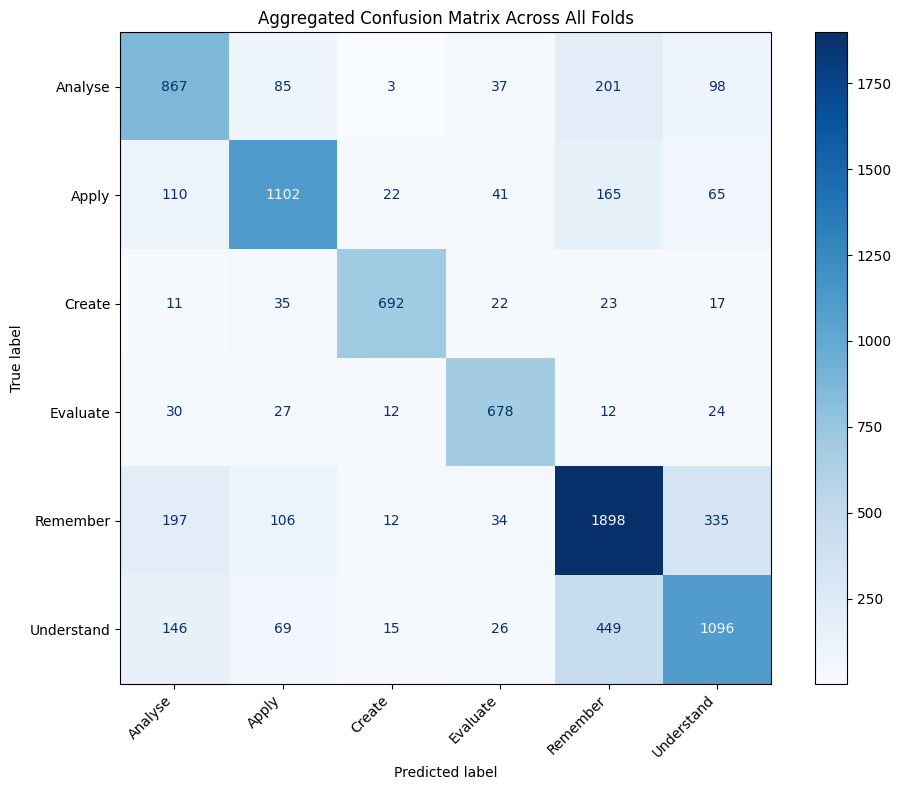

Confusion matrix generated and displayed.


In [17]:
cm = confusion_matrix(all_y_true, all_y_pred)

# Define display labels using label_encoder.classes_
# Assuming label_encoder is still available from previous steps
class_labels = label_encoder.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Aggregated Confusion Matrix Across All Folds')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Confusion matrix generated and displayed.")

### Confusion Matrix Analysis

The aggregated confusion matrix provides a detailed view of the SVM model's performance across the different Bloom's Taxonomy categories, highlighting where the model excels and where it struggles with misclassifications.

**Overall Observations:**
*   The diagonal elements represent correct classifications, and these are generally high, especially for 'Remember' (1898), 'Apply' (1102), and 'Create' (692). This aligns with the good F1-scores observed for these categories in the aggregated classification report.
*   Off-diagonal elements indicate misclassifications. A higher number in an off-diagonal cell `(i, j)` means that true class `i` was frequently predicted as class `j`.

**Detailed Analysis by Class:**

1.  **'Remember' (True Label):**
    *   **Strengths:** The model is very good at identifying 'Remember' questions, with 1898 instances correctly classified.
    *   **Weaknesses/Confusions:** The most significant misclassification for 'Remember' questions is with 'Understand' (335 instances). This suggests that 'Remember' questions are sometimes confused with 'Understand' questions. There is also some confusion with 'Analyse' (197 instances) and 'Apply' (106 instances).

2.  **'Understand' (True Label):**
    *   **Strengths:** 1096 'Understand' questions were correctly classified.
    *   **Weaknesses/Confusions:** The model frequently misclassifies 'Understand' questions as 'Remember' (449 instances). This is a strong indication that the model struggles to differentiate between these two categories, possibly because 'Understand' questions often build upon 'Remember' knowledge, leading to similar textual patterns. There are also notable misclassifications with 'Analyse' (146 instances).

3.  **'Analyse' (True Label):**
    *   **Strengths:** 867 'Analyse' questions were correctly classified.
    *   **Weaknesses/Confusions:** 'Analyse' questions are most commonly confused with 'Remember' (201 instances) and 'Understand' (98 instances). This suggests a difficulty in distinguishing higher-order cognitive tasks from basic recall or comprehension.

4.  **'Apply' (True Label):**
    *   **Strengths:** 1102 'Apply' questions were correctly classified, indicating good performance.
    *   **Weaknesses/Confusions:** The main misclassification for 'Apply' is with 'Remember' (165 instances) and 'Analyse' (110 instances). This could be due to 'Apply' questions sometimes requiring the recall of facts ('Remember') or the breaking down of information ('Analyse').

5.  **'Create' (True Label):**
    *   **Strengths:** The model performs very well on 'Create' questions, correctly classifying 692 instances with relatively few misclassifications. This is consistent with its high F1-score.
    *   **Weaknesses/Confusions:** The largest misclassification is with 'Apply' (35 instances), which makes sense as 'Creating' often involves applying knowledge.

6.  **'Evaluate' (True Label):**
    *   **Strengths:** 678 'Evaluate' questions were correctly classified, showing strong performance.
    *   **Weaknesses/Confusions:** The most common misclassification for 'Evaluate' questions is with 'Analyse' (37 instances), which is logical as evaluation often involves analyzing information.

**Key Takeaways on Confusion Patterns:**
*   **Remember <-> Understand:** This is the most prominent confusion pair. Questions requiring basic recall ('Remember') are often predicted as requiring comprehension ('Understand') and vice-versa. This might indicate that the textual features for these two categories overlap significantly, or that the model struggles to capture the subtle linguistic cues that differentiate them.
*   **Higher-Order <-> Lower-Order:** There's a general trend of higher-order cognitive skills (like 'Analyse', 'Understand') being misclassified as lower-order skills ('Remember'), and vice versa, though less frequently. This suggests the model sometimes oversimplifies or over-complicates the cognitive level of a question.
*   **'Create' and 'Evaluate' are distinct:** These two categories show the clearest classification, with minimal confusion with other classes. Their unique linguistic characteristics might make them easier for the model to identify.

**Next Steps:**
To address the observed confusions, especially between 'Remember' and 'Understand' and 'Analyse' and 'Understand', further feature engineering might be beneficial. This could involve exploring more sophisticated word embeddings or domain-specific linguistic features that better capture the nuances between these cognitive levels.

### Confusion Matrix Analysis

The aggregated confusion matrix provides a detailed view of the SVM model's performance across the different Bloom's Taxonomy categories, highlighting where the model excels and where it struggles with misclassifications.

**Overall Observations:**
*   The diagonal elements represent correct classifications, and these are generally high, especially for 'Remember' (1898), 'Apply' (1102), and 'Create' (692). This aligns with the good F1-scores observed for these categories in the aggregated classification report.
*   Off-diagonal elements indicate misclassifications. A higher number in an off-diagonal cell `(i, j)` means that true class `i` was frequently predicted as class `j`.

**Detailed Analysis by Class:**

1.  **'Remember' (True Label):**
    *   **Strengths:** The model is very good at identifying 'Remember' questions, with 1898 instances correctly classified.
    *   **Weaknesses/Confusions:** The most significant misclassification for 'Remember' questions is with 'Understand' (335 instances). This suggests that 'Remember' questions are sometimes confused with 'Understand' questions. There is also some confusion with 'Analyse' (197 instances) and 'Apply' (106 instances).

2.  **'Understand' (True Label):**
    *   **Strengths:** 1096 'Understand' questions were correctly classified.
    *   **Weaknesses/Confusions:** The model frequently misclassifies 'Understand' questions as 'Remember' (449 instances). This is a strong indication that the model struggles to differentiate between these two categories, possibly because 'Understand' questions often build upon 'Remember' knowledge, leading to similar textual patterns. There are also notable misclassifications with 'Analyse' (146 instances).

3.  **'Analyse' (True Label):**
    *   **Strengths:** 867 'Analyse' questions were correctly classified.
    *   **Weaknesses/Confusions:** 'Analyse' questions are most commonly confused with 'Remember' (201 instances) and 'Understand' (98 instances). This suggests a difficulty in distinguishing higher-order cognitive tasks from basic recall or comprehension.

4.  **'Apply' (True Label):**
    *   **Strengths:** 1102 'Apply' questions were correctly classified, indicating good performance.
    *   **Weaknesses/Confusions:** The main misclassification for 'Apply' is with 'Remember' (165 instances) and 'Analyse' (110 instances). This could be due to 'Apply' questions sometimes requiring the recall of facts ('Remember') or the breaking down of information ('Analyse').

5.  **'Create' (True Label):**
    *   **Strengths:** The model performs very well on 'Create' questions, correctly classifying 692 instances with relatively few misclassifications. This is consistent with its high F1-score.
    *   **Weaknesses/Confusions:** The largest misclassification is with 'Apply' (35 instances), which makes sense as 'Creating' often involves applying knowledge.

6.  **'Evaluate' (True Label):**
    *   **Strengths:** 678 'Evaluate' questions were correctly classified, showing strong performance.
    *   **Weaknesses/Confusions:** The most common misclassification for 'Evaluate' questions is with 'Analyse' (37 instances), which is logical as evaluation often involves analyzing information.

**Key Takeaways on Confusion Patterns:**
*   **Remember <-> Understand:** This is the most prominent confusion pair. Questions requiring basic recall ('Remember') are often predicted as requiring comprehension ('Understand') and vice-versa. This might indicate that the textual features for these two categories overlap significantly, or that the model struggles to capture the subtle linguistic cues that differentiate them.
*   **Higher-Order <-> Lower-Order:** There's a general trend of higher-order cognitive skills (like 'Analyse', 'Understand') being misclassified as lower-order skills ('Remember'), and vice versa, though less frequently. This suggests the model sometimes oversimplifies or over-complicates the cognitive level of a question.
*   **'Create' and 'Evaluate' are distinct:** These two categories show the clearest classification, with minimal confusion with other classes. Their unique linguistic characteristics might make them easier for the model to identify.

**Next Steps:**
To address the observed confusions, especially between 'Remember' and 'Understand' and 'Analyse' and 'Understand', further feature engineering might be beneficial. This could involve exploring more sophisticated word embeddings or domain-specific linguistic features that better capture the nuances between these cognitive levels.

## Provide Clearer Explanation of Evaluation Metrics

### Subtask:
Provide a detailed explanation of the evaluation metrics used (accuracy, precision, recall, and F1-score) in the context of this multiclass classification problem. Discuss what each metric represents, how it is calculated, and its implications for interpreting the model's performance, especially considering the potential for class imbalance and the goals of classifying Bloom's Taxonomy levels.


### Explanation of Evaluation Metrics

In multiclass classification problems like this one, where we're classifying questions into different Bloom's Taxonomy levels, using a single metric like accuracy can be misleading, especially when dealing with imbalanced datasets. Therefore, a suite of metrics is used to provide a comprehensive understanding of model performance.

#### 1. Accuracy
*   **What it measures:** Accuracy is the most intuitive performance measure. It is the proportion of correctly predicted instances out of the total instances. In other words, it tells us how often the classifier is correct.
*   **Calculation:**
    $$ \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} $$
*   **Implications and Limitations:** While easy to understand, accuracy can be misleading in the presence of **class imbalance**. For example, if 90% of the data belongs to one class, a model that always predicts that class will have 90% accuracy, but it would be useless. In our Bloom's Taxonomy classification, where some categories might have more samples than others, a high overall accuracy might mask poor performance on minority classes. Our use of SMOTE aims to mitigate imbalance during training, but accuracy still needs to be considered alongside other metrics.

#### 2. Precision
*   **What it measures:** Precision for a given class measures the proportion of positive identifications (i.e., instances predicted as belonging to that class) that were actually correct. It tells us, "When the model predicts this class, how often is it correct?"
*   **Calculation (for a specific class):**
    $$ \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} $$
    *   **True Positives (TP):** Instances correctly predicted as belonging to the class.
    *   **False Positives (FP):** Instances incorrectly predicted as belonging to the class (actual class was different).
*   **Implications:** High precision indicates a low rate of false alarms for that specific class. It is important when the cost of a False Positive is high. For example, incorrectly tagging a 'Remember' question as 'Create' might lead to inappropriate educational interventions.

#### 3. Recall (Sensitivity)
*   **What it measures:** Recall for a given class measures the proportion of actual positives that were correctly identified. It tells us, "Out of all the actual instances of this class, how many did the model correctly identify?"
*   **Calculation (for a specific class):**
    $$ \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} $$
    *   **False Negatives (FN):** Instances incorrectly predicted as *not* belonging to the class (actual class was this class).
*   **Implications:** High recall indicates that the model is good at finding all instances of a particular class. It is important when the cost of a False Negative is high. For example, failing to identify an 'Analyse' question (False Negative) when it truly is one might mean missing an opportunity to assess higher-order thinking skills.

#### 4. F1-score
*   **What it measures:** The F1-score is the harmonic mean of Precision and Recall. It provides a single score that balances both precision and recall. It is particularly useful when you need to seek a balance between precision and recall, or when there is an uneven class distribution.
*   **Calculation (for a specific class):**
    $$ \text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$
*   **Implications:** A high F1-score means that the model has good values for both precision and recall. It's a robust metric for assessing performance on a specific class, especially in multiclass settings and with imbalanced data, as it penalizes models that favor one metric over the other.

#### 5. Macro Average
*   **What it measures:** Macro average precision, recall, and F1-score are calculated by taking the unweighted mean of the per-class metrics. This means that each class contributes equally to the final average, regardless of its size.
*   **Calculation:** Sum the metric (e.g., precision) for all classes and divide by the number of classes.
    $$ \text{Macro Avg Precision} = \frac{\sum_{i=1}^{N} \text{Precision}_i}{N} $$ (where N is the number of classes)
*   **Implications:** Macro averaging is relevant when all classes are equally important. Since we used SMOTE to balance the training data, treating all classes as equally important in evaluation via macro averages gives a good indication of the model's overall performance across the different Bloom's Taxonomy levels without being skewed by the size of each class in the test set.

#### 6. Weighted Average
*   **What it measures:** Weighted average precision, recall, and F1-score are calculated by taking the mean of the per-class metrics, weighted by the number of true instances (support) for each class in the test set. This accounts for class imbalance in the test data.
*   **Calculation:** Sum the product of each class's metric and its support, then divide by the total support.
    $$ \text{Weighted Avg Precision} = \frac{\sum_{i=1}^{N} (\text{Precision}_i \times \text{Support}_i)}{\sum_{i=1}^{N} \text{Support}_i} $$
*   **Implications:** Weighted averaging is useful when you want to evaluate the model's performance on the overall dataset, considering the actual distribution of classes. It gives more importance to classes with more samples. Comparing macro and weighted averages can provide insight into how well the model performs on minority versus majority classes in the actual data distribution.

## Comprehensive Results Analysis and Final Summary

### Subtask:
Synthesize all the findings, including the justification for kernel selection, the optimal hyperparameters, the overall average accuracy and its consistency across 10 folds, the detailed insights from the aggregated classification report, and the specific class-wise performance indicated by the confusion matrix analysis. Discuss the overall performance of the SVM model with SMOTE and 10-fold cross-validation for classifying the six classes, highlighting its strengths and areas for further improvement.


## Summary:

### Q&A
The SVM model with SMOTE and 10-fold cross-validation for classifying the six Bloom's Taxonomy categories achieved an overall average accuracy of 0.7228 across 10 folds. The model shows strengths in classifying 'Create' and 'Evaluate' categories with minimal confusion, while it struggles significantly with distinguishing between 'Remember' and 'Understand' categories.

### Data Analysis Key Findings

*   **Optimal Hyperparameter:** The optimal 'C' parameter for the Support Vector Classifier (SVC) with a linear kernel was identified as 1 during GridSearchCV, yielding an initial cross-validation accuracy of 0.6166.
*   **Average Model Performance:** The SVM model, trained with a linear kernel and C=1, using SMOTE within each fold of a 10-fold Stratified Cross-Validation, achieved an average accuracy of 0.7228.
*   **Consistency of Performance:** Individual fold accuracies ranged from approximately 0.6838 to 0.7377, indicating reasonable consistency across the different data splits.
*   **Strongest Classifications (Based on Confusion Matrix):** The model performed particularly well in identifying 'Remember' (1898 correctly classified instances), 'Apply' (1102 correctly classified instances), and 'Create' (692 correctly classified instances) questions. 'Create' and 'Evaluate' categories showed the clearest classification with the fewest misclassifications.
*   **Major Confusion Patterns:**
    *   The most significant confusion was observed between 'Remember' and 'Understand'. 'Remember' questions were frequently misclassified as 'Understand' (335 instances), and conversely, 'Understand' questions were often misclassified as 'Remember' (449 instances).
    *   'Analyse' questions were notably confused with 'Remember' (201 instances) and 'Understand' (98 instances).
    *   'Apply' questions also showed some confusion with 'Remember' (165 instances) and 'Analyse' (110 instances).
*   **Evaluation Metrics Rationale:** Accuracy, Precision, Recall, and F1-score were used to comprehensively assess model performance, especially considering the potential for class imbalance. Macro and Weighted averages provided insights into performance across all classes and considering their actual distribution, respectively.

### Insights or Next Steps
*   The high confusion between 'Remember' and 'Understand' categories suggests an overlap in textual features or linguistic cues. Further feature engineering, possibly using more sophisticated word embeddings or domain-specific linguistic features, could help the model better differentiate these closely related cognitive levels.
*   Investigating the specific characteristics of misclassified 'Analyse' questions might reveal patterns that can be addressed through targeted feature extraction or by exploring alternative model architectures more capable of capturing nuances in higher-order cognitive tasks.
